# Stage 2: Multi-agents


In [ ]:
# !pip -q install langgraph langchain-openai openai python-dotenv pydantic


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1) Imports

In [1]:
import os
from dotenv import load_dotenv
from typing import TypedDict, Annotated, List, Dict, Any, Optional, Literal
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage, AnyMessage
from langchain_core.tools import tool
from langgraph.graph import StateGraph, START, END
from langgraph.checkpoint.memory import MemorySaver
from langgraph.prebuilt import create_react_agent
from langgraph.graph.message import add_messages



## 2) Load environment variables


In [2]:
# if you are running in local, uncomment below line. also make sure you shall have a .env file
load_dotenv()

True

In [3]:
# if you are running in google colab, uncomment below line. and replace "Your_API_Key" with your own openAI API key
#os.environ["OPENAI_API_KEY"] = "Your_API_Key"

## 3) Shared State + Helpers

In [4]:
Route = Literal["extract", "supervisor", "research", "cost", "planner", "finish"]

class TripSpec(TypedDict, total=False):
    destination: str
    days: int
    travelers: int
    comfort: str               # budget|mid|premium
    preferences: str
    total_days: int

class State(TypedDict):
    messages: Annotated[List[AnyMessage], add_messages]
    trip_spec: TripSpec
    research_notes: str
    cost_breakdown: Dict[str, Any]
    itinerary: str
    task: str                  # message produced by supervisor for next specialist
    next: Optional[str]

def pretty_print(response):
    last_msg = response["messages"][-1]

    if isinstance(last_msg.content, list):
        text = "".join(
            block["text"]
            for block in last_msg.content
            if block.get("type") == "text"
        )
    else:
        text = last_msg.content
    print(text)

def msg_text(msg: AnyMessage) -> str:
    c = msg.content
    if isinstance(c, list):  # Responses API content blocks
        return "".join(block.get("text", "") for block in c if block.get("type") == "text")
    return str(c)


## 4) Local Tool: estimate_trip_cost

In [5]:
@tool
def estimate_trip_cost(
    destination: str,
    days: int,
    travelers: int,
    comfort: str = "mid",
) -> Dict[str, Any]:
    """Estimate a rough trip budget (SGD) using simple heuristics. Excludes flights/insurance/visa."""
    if days <= 0 or travelers <= 0:
        raise ValueError("days and travelers must be > 0")

    comfort = comfort.lower().strip()
    if comfort not in {"budget", "mid", "premium"}:
        raise ValueError("comfort must be one of: budget, mid, premium")

    # Very rough per-person-per-day estimates (SGD) excluding flights
    lodging_per_person_per_day = {"budget": 60, "mid": 140, "premium": 300}[comfort]
    food_per_person_per_day = {"budget": 30, "mid": 60, "premium": 120}[comfort]
    local_transport_per_person_per_day = {"budget": 10, "mid": 20, "premium": 50}[comfort]
    activities_per_person_per_day = {"budget": 20, "mid": 50, "premium": 120}[comfort]

    lodging = lodging_per_person_per_day * travelers * days
    food = food_per_person_per_day * travelers * days
    transport = local_transport_per_person_per_day * travelers * days
    activities = activities_per_person_per_day * travelers * days

    subtotal = lodging + food + transport + activities
    contingency = round(subtotal * 0.12)
    total = subtotal + contingency

    return {
        "destination": destination,
        "days": days,
        "travelers": travelers,
        "comfort": comfort,
        "currency": "SGD",
        "breakdown": {
            "lodging": lodging,
            "food": food,
            "local_transport": transport,
            "activities": activities,
            "contingency": contingency,
        },
        "total_estimate": total,
        "note": "Heuristic estimate excludes international flights/insurance/visa fees.",
    }


## 5) Memory

In [6]:
checkpointer = MemorySaver()

## 7) Create Specialist Agents

In [7]:
RESEARCH_SYSTEM = """You are ResearchAgent.
Your ONLY job: gather factual, practical travel info using web search.
Rules:
- Use web search when needed.
- Do NOT estimate or compute cost.
- Output ONLY 5 bullets max.
- Each bullet: destination + why + travel time + one practical note.
"""

research_agent = create_react_agent(
    model=ChatOpenAI(model="gpt-4.1-mini", temperature=0.2),
    tools=[{"type": "web_search_preview"}],
    prompt=RESEARCH_SYSTEM,
    checkpointer=checkpointer,
    name="research_agent",
)

C:\Users\sreer\AppData\Local\Temp\ipykernel_5584\1678152761.py:10: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  research_agent = create_react_agent(


In [8]:

COST_SYSTEM = """You are CostAgent.
Your ONLY job: compute total cost using the estimate_trip_cost tool.
Rules:
- Never invent numbers.
- If destination/days/travelers/comfort are missing, ask for them and stop.
- If user says 'add an additional one-day trip', treat it as +1 day ONLY IF baseline days is known.
"""
cost_agent = create_react_agent(
    model=ChatOpenAI(model="gpt-4.1-mini", temperature=0.1),
    tools=[estimate_trip_cost],
    prompt=SystemMessage(content=COST_SYSTEM),
    checkpointer=checkpointer,
    name="cost_agent",
)

C:\Users\sreer\AppData\Local\Temp\ipykernel_5584\1877747532.py:8: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  cost_agent = create_react_agent(


In [9]:
ITINERARY_SYSTEM = """You are PlannerAgent.
Your job: produce the final itinerary using trip_spec + research_notes + cost_breakdown.
Rules:
- Do NOT invent numeric costs; use cost_breakdown only.
Output format:
1) Day-by-day plan (brief)
2) Total cost (SGD) + assumptions
"""
itinerary_agent = create_react_agent(
    model=ChatOpenAI(model="gpt-4.1-mini", temperature=0.4),
    tools=[],
    prompt=SystemMessage(content=ITINERARY_SYSTEM),
    checkpointer=checkpointer,
    name="itinerary_agent",
)

C:\Users\sreer\AppData\Local\Temp\ipykernel_5584\53405884.py:9: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  itinerary_agent = create_react_agent(


## Supervisor Agent

In [10]:
SUPERVISOR_SYSTEM = """You are SupervisorAgent coordinating 3 specialists: ResearchAgent, CostAgent, PlannerAgent.

You must decide the NEXT step and craft the exact task message for that specialist.

Available specialists:
- research_agent: find factual day-trip / transport / opening hours info (uses web search). Never compute cost.
- cost_agent: compute total cost using estimate_trip_cost tool.
- itinerary_agent: compose final answer using trip_spec + research_notes + cost_breakdown.

Rules:
- NEVER guess missing numbers. If days/travelers/comfort missing and user asks for total cost, route to itinerary_agent with a task that asks a short clarification question.
- If user asks for day trip options, route to research_agent.
- If cost requested AND required params exist, route to cost_agent.
- If research_notes and cost_breakdown exist, route to itinerary_agent to compose the final answer.
- task must be concise and include relevant state values.

Return STRICT JSON: {"next":..., "task":...}
"""

supervisor_agent = create_react_agent(
    model=ChatOpenAI(model="gpt-4.1-mini", temperature=0),
    tools=[],
    prompt=SUPERVISOR_SYSTEM,
    checkpointer=checkpointer,
    name="supervisor_agent",
)

C:\Users\sreer\AppData\Local\Temp\ipykernel_5584\351586815.py:20: LangGraphDeprecatedSinceV10: create_react_agent has been moved to `langchain.agents`. Please update your import to `from langchain.agents import create_agent`. Deprecated in LangGraph V1.0 to be removed in V2.0.
  supervisor_agent = create_react_agent(


## 8) TripSpec Extractor Node

In [11]:
def extract_trip_spec_node(state: State):

    trip = state.get("trip_spec", {}) or {}
    text = msg_text(state["messages"][-1]).lower()

    llm = ChatOpenAI(model="gpt-4.1-mini",temperature=0).with_structured_output(TripSpec)

    tripSpec = llm.invoke(text +" extract the  destination, no. of days, no. of travelers, comfort (budget|mid|premium), preferences.")

    return {
         "trip_spec": tripSpec
    }

## 9) Supervisor Agent node

In [12]:
def supervisor_agent_node(state: State):
    trip = state.get("trip_spec", {}) or {}
    have_research = bool((state.get("research_notes") or "").strip())
    have_cost = bool(state.get("cost_breakdown"))

    last_user = msg_text(state["messages"][-1])

    prompt = (
        f"TripSpec: {trip}\n"
        f"have_research_notes: {have_research}\n"
        f"have_cost_breakdown: {have_cost}\n"
        f"research_notes: {(state.get('research_notes') or '')[:600]}\n"
        f"cost_breakdown: {state.get('cost_breakdown') or {}}\n\n"
        f"User message: {last_user}"
    )

    decision = supervisor_agent.invoke({"messages": [HumanMessage(content=prompt)]}, config=state.get("_config"))

    import json
    text = msg_text(decision["messages"][-1]).strip()
    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        # try to salvage first {...} block
        start = text.find("{")
        end = text.rfind("}")
        if start == -1 or end == -1 or end <= start:
            # fallback: route to planner with a clarification task
            return {
                "next": "planner",
                "task": "Ask a short clarification: confirm destination, days, travelers, comfort.",
            }
        data = json.loads(text[start : end + 1])
    print("----------"+json.dumps(data, indent=2))

    return{
        "next": data["next"],
        "task": data["task"]
    }

## 10) Specialist Agent Nodes

In [13]:
def research_node(state: State):
    task = state.get("task", "")
    result = research_agent.invoke(
        {"messages": [HumanMessage(content=task)]},
        config=state.get("_config"),
    )
    out = result["messages"][-1]
    return {
        "research_notes": msg_text(out),
        "messages": [AIMessage(content=msg_text(out), name="research_agent")],
    }

In [14]:
def cost_node(state: State):
    trip = state.get("trip_spec", {}) or {}
    required = ("destination", "days", "travelers", "comfort")
    missing = [k for k in required if k not in trip]
    if missing:
        return {
            "messages": [AIMessage(content=f"Missing required fields for cost: {missing}.", name="cost_agent")],
        }

    # Human-friendly phrasing via CostAgent
    task = state.get("task", "")
    result = cost_agent.invoke({"messages": [HumanMessage(content=task)]}, config=state.get("_config"))
    out = result["messages"][-1]

    return {
        "trip_spec": trip,
        "cost_breakdown": msg_text(out),
        "messages": [AIMessage(content=msg_text(out), name="cost_agent")],
    }

In [15]:
def itinerary_node(state: State):
    task = state.get("task", "")
    # Provide planner full context as a single task (supervisor should craft it, but we also attach state)
    trip = state.get('trip_spec', {}) or {}
    research = state.get('research_notes') or ''
    cost = state.get('cost_breakdown') or {}

    enriched_task = (
        f"{task}\n\n"
        f"TripSpec: {trip}\n\n"
        f"Research notes:\n{research}\n\n"
        f"Cost breakdown (JSON):\n{cost}"
    )

    result = itinerary_agent.invoke({"messages": [HumanMessage(content=enriched_task)]}, config=state.get("_config"))
    out = result["messages"][-1]

    return { "itinerary": msg_text(out),
        "messages": [AIMessage(content=msg_text(out), name="planner_agent")]}

## 11) Build Graph

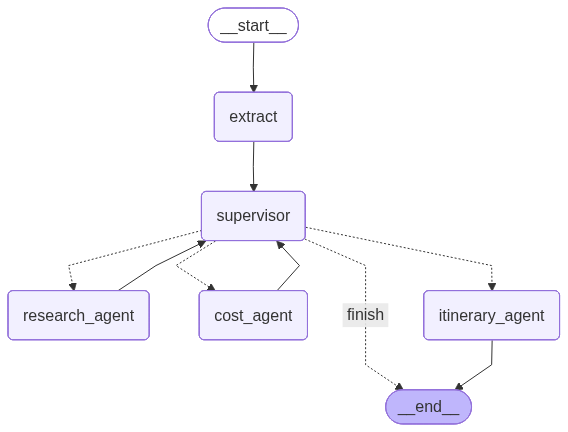

In [16]:
def route(state: State):
    return state.get("next", "itinerary_agent")

builder = StateGraph(State)
builder.add_node("extract", extract_trip_spec_node)
builder.add_node("supervisor", supervisor_agent_node)  # <-- supervisor is an agent node
builder.add_node("research_agent", research_node)
builder.add_node("cost_agent", cost_node)
builder.add_node("itinerary_agent", itinerary_node)

builder.add_edge(START, "extract")
builder.add_edge("extract", "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route,
    {
        "research_agent": "research_agent",
        "cost_agent": "cost_agent",
        "itinerary_agent": "itinerary_agent",
        "finish": END,
    },
)

builder.add_edge("research_agent", "supervisor")
builder.add_edge("cost_agent", "supervisor")
builder.add_edge("itinerary_agent", END)

graph = builder.compile(checkpointer=checkpointer)

from IPython.display import Image, display
display(Image(graph.get_graph().draw_mermaid_png()))


## 12) Demo

In [17]:
print("=== Stage 2 Demo (Supervisor Agent) ===")

config_a = {"configurable": {"thread_id": "A"}}
user_prompt = "Plan a 2-day Tokyo trip for 2 adults, mid comfort. We like food and anime. Avoid packed schedules."

resp1 = graph.invoke(
    {"messages": [{"role": "user", "content": user_prompt}]}, config=config_a
)
print("\n--- Turn 1 ---")
pretty_print(resp1)


=== Stage 2 Demo (Supervisor Agent) ===
----------{
  "next": "research_agent",
  "task": "Find factual day-trip and opening hours information for a 2-day trip to Tokyo for 2 adults with mid comfort, focusing on food and anime, avoiding packed schedules."
}
----------{
  "next": "cost_agent",
  "task": "Calculate total cost for a 2-day Tokyo trip for 2 travelers with mid comfort, focusing on food and anime."
}
----------{
  "next": "itinerary_agent",
  "task": "Compose the final answer using the provided trip_spec, research_notes, and cost_breakdown for a 2-day Tokyo trip for 2 travelers with mid comfort focusing on food and anime."
}

--- Turn 1 ---
1) Day-by-day plan:

Day 1: Akihabara Exploration  
- Spend the day exploring Akihabara, Tokyo’s anime and electronics district.  
- Visit various anime shops and themed cafes for immersive dining experiences inspired by popular anime series.  
- Plan meals before 10 pm as many restaurants close early.  

Day 2: Nakano Broadway and Tokyo S